# DMS Analysis: SARS-CoV-2 Spike — EnrichR2 Pipeline

An updated pipeline using **EnrichR2** scoring: instead of discarding low-coverage mutations with a hard count filter, all mutations are retained and down-weighted by their measurement variance.

| | Standard (Notebook 1) | EnrichR2 (this notebook) |
|---|---|---|
| Coverage filter | `expected_count ≥ 20` (hard cutoff) | None — soft weighting |
| Score per mutation | Simple mean of log₂ enrichment | Inverse-variance weighted mean |
| Noisy measurements | Discarded | Down-weighted |

In [2]:
import pandas as pd
import numpy as np
import re
import requests
from functools import reduce
import matplotlib.pyplot as plt
from scipy import stats

## 1. Imports

In [3]:
#python# ============================================================
#  Load Bloom & Neher fitness estimates
# KEY CHANGE: We do NOT apply expected_count >= 20 filter.
# Instead we keep ALL mutations and will use expected_count
# as a weight (EnrichR2 philosophy: downweight, don't discard).
# ============================================================
url = ("https://raw.githubusercontent.com/jbloomlab/SARS2-mut-fitness"
       "/main/results/aa_fitness/aamut_fitness_all.csv")
fitness_df = pd.read_csv(url)
fitness_df.columns = fitness_df.columns.str.lower()

# DO NOT filter here — keep all rows, including low expected_count
print("Full fitness df shape (no filter):", fitness_df.shape)
print("Rows with expected_count < 20:", (fitness_df['expected_count'] < 20).sum())
print("Rows with expected_count >= 20:", (fitness_df['expected_count'] >= 20).sum())
print(fitness_df.columns.tolist())

Full fitness df shape (no filter): (122451, 12)
Rows with expected_count < 20: 33844
Rows with expected_count >= 20: 88607
['gene', 'clade_founder_aa', 'mutant_aa', 'aa_site', 'aa_mutation', 'subset_of_orf1ab', 'expected_count', 'actual_count', 'count_terminal', 'count_non_terminal', 'mean_log_size', 'delta_fitness']


## 2. Load Bloom & Neher Fitness Estimates (No Hard Filter)

Loads all mutations without applying a coverage cutoff. `expected_count` is retained as a continuous weight for downstream weighted correlation.

In [4]:
bv_url = ("https://raw.githubusercontent.com/dms-vep/"
          "SARS-CoV-2_Omicron_BA.1_spike_DMS_mAbs/main/"
          "results/variants/codon_variants.csv")
bv_table = pd.read_csv(bv_url)
print("Barcode table shape:", bv_table.shape)
print(bv_table.columns.tolist())

Barcode table shape: (360141, 8)
['target', 'library', 'barcode', 'variant_call_support', 'codon_substitutions', 'aa_substitutions', 'n_codon_substitutions', 'n_aa_substitutions']


## 3. Load Spike Barcode-Variant Lookup Table

In [5]:
repo     = "dms-vep/SARS-CoV-2_Omicron_BA.1_spike_DMS_mAbs"
api_url  = f"https://api.github.com/repos/{repo}/contents/results/variant_counts"
raw_base = f"https://raw.githubusercontent.com/{repo}/main/results/variant_counts/"

response = requests.get(api_url)
files = [f["name"] for f in response.json() if f["name"].endswith(".csv")]
print(f"Files found: {len(files)}")

all_counts = []
for f in files:
    try:
        df = pd.read_csv(raw_base + f)
        df["sample_file"] = f
        all_counts.append(df)
    except Exception as e:
        print(f"  SKIP {f}: {e}")

counts_df = pd.concat(all_counts, ignore_index=True)
print("counts_df shape:", counts_df.shape)


Files found: 37
counts_df shape: (4398804, 12)


## 4. Download Variant Count Data

Barcodes in both VSVG replicates: 94355
VSVG replicate Pearson r = 0.9592  (p = 0.00e+00)


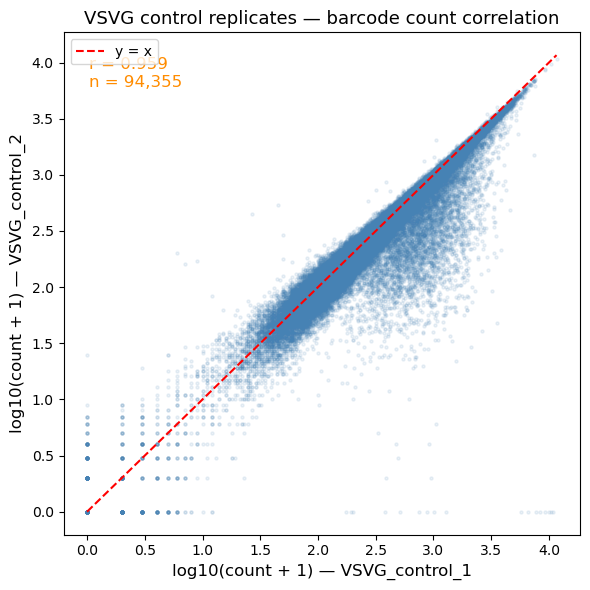

In [6]:
#  VSVG replicate correlation (NEW)
# This is the quality control check your guide asked for.
# We compare VSVG_control_1 vs VSVG_control_2 to verify
# that technical replicates are consistent.
# ============================================================

# Extract the two VSVG replicates separately
vsvg1 = (counts_df[counts_df["sample_file"].str.contains("VSVG_control_1")]
         .groupby("barcode")["count"].sum()
         .reset_index()
         .rename(columns={"count": "vsvg_rep1"}))

vsvg2 = (counts_df[counts_df["sample_file"].str.contains("VSVG_control_2")]
         .groupby("barcode")["count"].sum()
         .reset_index()
         .rename(columns={"count": "vsvg_rep2"}))

vsvg_both = vsvg1.merge(vsvg2, on="barcode", how="inner")
print(f"Barcodes in both VSVG replicates: {len(vsvg_both)}")

# Log-transform for visualization (add pseudocount)
vsvg_both["log_rep1"] = np.log10(vsvg_both["vsvg_rep1"] + 1)
vsvg_both["log_rep2"] = np.log10(vsvg_both["vsvg_rep2"] + 1)

# Pearson correlation
r_vsvg, p_vsvg = stats.pearsonr(vsvg_both["log_rep1"], vsvg_both["log_rep2"])
print(f"VSVG replicate Pearson r = {r_vsvg:.4f}  (p = {p_vsvg:.2e})")

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(vsvg_both["log_rep1"], vsvg_both["log_rep2"],
           alpha=0.1, s=5, color="steelblue")
mn = min(vsvg_both["log_rep1"].min(), vsvg_both["log_rep2"].min())
mx = max(vsvg_both["log_rep1"].max(), vsvg_both["log_rep2"].max())
ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label="y = x")
ax.set_xlabel("log10(count + 1) — VSVG_control_1", fontsize=12)
ax.set_ylabel("log10(count + 1) — VSVG_control_2", fontsize=12)
ax.set_title("VSVG control replicates — barcode count correlation", fontsize=13)
ax.text(0.05, 0.95, f"r = {r_vsvg:.3f}\nn = {len(vsvg_both):,}",
        transform=ax.transAxes, va="top", fontsize=12, color="darkorange")
ax.legend()
plt.tight_layout()
plt.savefig("vsvg_replicate_correlation.png", dpi=300, bbox_inches="tight")
plt.show()




## 5. Quality Control: VSVG Replicate Correlation

Compares barcode counts between `VSVG_control_1` and `VSVG_control_2` to verify technical replicate consistency. High Pearson *r* confirms the library sampling is reproducible.

In [7]:
input_mask  = counts_df["sample_file"].str.contains("VSVG_control")
output_mask = counts_df["sample_file"].str.contains("no-antibody_control")

input_counts = (counts_df[input_mask]
    .groupby("barcode")["count"].sum()
    .reset_index()
    .rename(columns={"count": "count_input"}))

output_counts = (counts_df[output_mask]
    .groupby("barcode")["count"].sum()
    .reset_index()
    .rename(columns={"count": "count_output"}))

print("Input barcodes: ", len(input_counts))
print("Output barcodes:", len(output_counts))


Input barcodes:  354309
Output barcodes: 354309


## 6. Split Input vs Output Samples and Aggregate

In [8]:
# ============================================================
#  EnrichR2 functional score (MAJOR UPDATE)
#
# KEY CHANGE from your original code:
# OLD: simple log2(freq_out / freq_in), then mean per mutation
# NEW: inverse-variance weighted mean per mutation (EnrichR2)
#
# The weight for each barcode = 1 / var_i
# where var_i = (1/count_out_i + 1/count_in_i)
# (delta method approximation of variance of log-ratio)
#
# This means:
#   - Barcodes with 100 counts → low variance → HIGH weight
#   - Barcodes with 2 counts   → high variance → LOW weight
#   - No mutation is discarded; noisy ones just contribute less
# ============================================================

pseudocount = 0.5

# Merge counts with barcode-variant table
merged = input_counts.merge(output_counts, on="barcode", how="inner")
merged = merged.merge(
    bv_table[["barcode", "library", "aa_substitutions", "n_aa_substitutions"]],
    on="barcode",
    how="inner"
)
print("Merged shape:", merged.shape)

# ---- Single mutants only ----
single_muts = merged[merged["n_aa_substitutions"] == 1].copy()
print("Single mutants:", len(single_muts))

# ---- Global totals for frequency normalisation ----
total_input  = single_muts["count_input"].sum()
total_output = single_muts["count_output"].sum()

# ---- Per-barcode log2 enrichment (same formula as before) ----
single_muts["freq_input"]  = (single_muts["count_input"]  + pseudocount) / (total_input  + pseudocount)
single_muts["freq_output"] = (single_muts["count_output"] + pseudocount) / (total_output + pseudocount)
single_muts["log2_enrich"] = np.log2(single_muts["freq_output"] / single_muts["freq_input"])

# ---- EnrichR2 weights ----
# Variance of log(n_out/n_in) ≈ 1/n_out + 1/n_in  (delta method)
# We add pseudocount to avoid division by zero
single_muts["var_enrich"] = (
    1.0 / (single_muts["count_output"] + pseudocount) +
    1.0 / (single_muts["count_input"]  + pseudocount)
)
# Weight = 1 / variance (inverse-variance weighting)
single_muts["weight"] = 1.0 / single_muts["var_enrich"]

# ---- Weighted mean per mutation (EnrichR2 score) ----
def weighted_mean(group):
    w = group["weight"]
    s = group["log2_enrich"]
    wm = (w * s).sum() / w.sum()
    # Effective number of barcodes (not just count; accounts for quality)
    n_barcodes = len(group)
    sum_weights = w.sum()
    return pd.Series({"dms_score": wm,
                       "n_barcodes": n_barcodes,
                       "sum_weights": sum_weights})

spike_scores = (
    single_muts
    .groupby("aa_substitutions")
    .apply(weighted_mean)
    .reset_index()
)

print("Spike mutations with EnrichR2 scores:", len(spike_scores))
print(spike_scores.head())

# Compare: how many mutations did we GAIN by not hard-filtering?
# (The hard filter n_barcodes >= 3 is still reasonable, but optional)
print("\nDistribution of n_barcodes per mutation:")
print(spike_scores["n_barcodes"].describe())

Merged shape: (360141, 6)
Single mutants: 102250
Spike mutations with EnrichR2 scores: 8331
  aa_substitutions  dms_score  n_barcodes   sum_weights
0           *1250R   0.861356        32.0  10604.018386
1           *1250S   0.900253         1.0    145.551855
2           *1250W   3.035023         1.0    158.916931
3           A1012D  -6.441081         2.0      1.980182
4           A1012Q  -1.745322         3.0     58.702977

Distribution of n_barcodes per mutation:
count    8331.000000
mean       12.273437
std        15.558599
min         1.000000
25%         3.000000
50%         7.000000
75%        15.000000
max       153.000000
Name: n_barcodes, dtype: float64


## 7. EnrichR2 Functional Scores

Each barcode's log₂ enrichment score is weighted by `1 / variance`, where variance is estimated from Poisson counting noise in input and output reads. The per-mutation score is the **inverse-variance weighted mean** across all barcodes carrying that mutation — giving more weight to high-coverage barcodes.


--- Running enrichR2 for input pattern: 'VSVG_control_1' ---
  Input rows matched:  360141
  Output rows matched: 454496
  Input barcodes:  354309
  Output barcodes: 354309
  Single-mutant barcodes: 102250
  WT mean (weighted)   = 0.2773
  Stop mean (weighted) = -0.9891
  Mutations scored (n_barcodes >= 2): 7135

--- Running enrichR2 for input pattern: 'VSVG_control_2' ---
  Input rows matched:  94355
  Output rows matched: 454496
  Input barcodes:  94355
  Output barcodes: 354309
  Single-mutant barcodes: 28155
  WT mean (weighted)   = 0.1425
  Stop mean (weighted) = -0.3170
  Mutations scored (n_barcodes >= 2): 4467

Mutations in both replicates: 4467
  aa_substitutions  dms_score_norm_rep1  dms_score_norm_rep2
0           *1250R             0.336464             1.400831
1           A1012S            -0.531258            -0.325955
2           A1012V            -2.643671            -9.756864
3           A1013D            -1.179818             0.337960
4           A1013L            -0

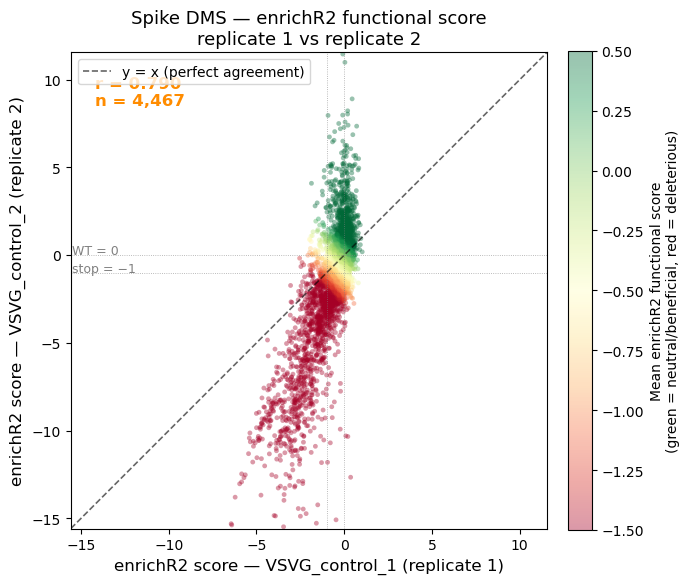


Saved: vsvg_enrichR2_replicate_correlation.png

Summary:
  Cell 5 (count QC):          r = 0.9592  — raw barcode counts agree
  This cell (functional QC):  r = 0.7895  — enrichR2 scores agree
  Both should be high. If the functional r is much lower than count r,
  it means sequencing is consistent but the enrichment is noisy.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats

pseudocount = 0.5

# ============================================================
# STEP 1 — Define a function that runs the full enrichR2 pipeline
#          for a given set of input files (one replicate at a time)
# ============================================================

def compute_enrichR2_scores(counts_df, bv_table, input_pattern, output_pattern="no-antibody_control"):
    """
    Runs the complete enrichR2 pipeline for one set of input files.

    Parameters
    ----------
    counts_df       : full counts dataframe (from Cell 4)
    bv_table        : barcode-variant table (from Cell 3)
    input_pattern   : string to match input sample files, e.g. "VSVG_control_1"
    output_pattern  : string to match output sample files (same for both replicates)

    Returns
    -------
    DataFrame with columns: aa_substitutions, dms_score, dms_score_norm, n_barcodes
    """

    # --- 1a. Extract input counts for this replicate only ---
    input_mask  = counts_df["sample_file"].str.contains(input_pattern)
    output_mask = counts_df["sample_file"].str.contains(output_pattern)

    print(f"\n--- Running enrichR2 for input pattern: '{input_pattern}' ---")
    print(f"  Input rows matched:  {input_mask.sum()}")
    print(f"  Output rows matched: {output_mask.sum()}")

    inp = (counts_df[input_mask]
           .groupby("barcode")["count"].sum()
           .reset_index()
           .rename(columns={"count": "count_input"}))

    out = (counts_df[output_mask]
           .groupby("barcode")["count"].sum()
           .reset_index()
           .rename(columns={"count": "count_output"}))

    print(f"  Input barcodes:  {len(inp)}")
    print(f"  Output barcodes: {len(out)}")

    # --- 1b. Merge counts with barcode-variant table ---
    merged = inp.merge(out, on="barcode", how="inner")
    merged = merged.merge(
        bv_table[["barcode", "aa_substitutions", "n_aa_substitutions"]],
        on="barcode", how="inner"
    )

    # --- 1c. Single mutants only ---
    single = merged[merged["n_aa_substitutions"] == 1].copy()
    print(f"  Single-mutant barcodes: {len(single)}")

    if len(single) == 0:
        print("  ERROR: No single mutants found — check input_pattern")
        return None

    # --- 1d. Frequency normalisation ---
    T_in  = single["count_input"].sum()
    T_out = single["count_output"].sum()

    single["freq_in"]  = (single["count_input"]  + pseudocount) / (T_in  + pseudocount)
    single["freq_out"] = (single["count_output"] + pseudocount) / (T_out + pseudocount)
    single["log2E"]    = np.log2(single["freq_out"] / single["freq_in"])

    # --- 1e. enrichR2 inverse-variance weights ---
    # var(log2E) ≈ 1/count_out + 1/count_in  (delta method)
    single["var"] = (1.0 / (single["count_output"] + pseudocount) +
                     1.0 / (single["count_input"]  + pseudocount))
    single["w"]   = 1.0 / single["var"]

    # --- 1f. Weighted mean per mutation ---
    def wmean(g):
        return pd.Series({
            "dms_score":   (g["w"] * g["log2E"]).sum() / g["w"].sum(),
            "n_barcodes":  len(g),
            "sum_weights": g["w"].sum()
        })

    scores = (single.groupby("aa_substitutions")
              .apply(wmean)
              .reset_index())

    # --- 1g. Normalise: WT = 0, stop codon = -1 ---
    wt_rows   = merged[merged["n_aa_substitutions"] == 0].copy()
    stop_rows = merged[merged["aa_substitutions"].str.contains(r"\*", na=False)].copy()

    for df in [wt_rows, stop_rows]:
        df["freq_in"]  = (df["count_input"]  + pseudocount) / (T_in  + pseudocount)
        df["freq_out"] = (df["count_output"] + pseudocount) / (T_out + pseudocount)
        df["log2E"]    = np.log2(df["freq_out"] / df["freq_in"])
        df["var"]      = (1.0 / (df["count_output"] + pseudocount) +
                          1.0 / (df["count_input"]  + pseudocount))
        df["w"]        = 1.0 / df["var"]

    if len(wt_rows) == 0 or len(stop_rows) == 0:
        print("  WARNING: No WT or stop barcodes — cannot normalise. Returning raw scores.")
        scores["dms_score_norm"] = scores["dms_score"]
    else:
        wt_mean   = (wt_rows["w"]   * wt_rows["log2E"]).sum()   / wt_rows["w"].sum()
        stop_mean = (stop_rows["w"] * stop_rows["log2E"]).sum() / stop_rows["w"].sum()
        print(f"  WT mean (weighted)   = {wt_mean:.4f}")
        print(f"  Stop mean (weighted) = {stop_mean:.4f}")
        scores["dms_score_norm"] = (scores["dms_score"] - wt_mean) / (wt_mean - stop_mean)

    # --- 1h. Require at least 2 barcodes ---
    scores = scores[scores["n_barcodes"] >= 2].copy()
    print(f"  Mutations scored (n_barcodes >= 2): {len(scores)}")

    return scores


# ============================================================
# STEP 2 — Run the pipeline separately for rep1 and rep2
# ============================================================

scores_rep1 = compute_enrichR2_scores(counts_df, bv_table,
                                       input_pattern="VSVG_control_1")

scores_rep2 = compute_enrichR2_scores(counts_df, bv_table,
                                       input_pattern="VSVG_control_2")


# ============================================================
# STEP 3 — Merge rep1 and rep2 on mutation identity
# ============================================================

rep_corr = scores_rep1[["aa_substitutions", "dms_score_norm"]].merge(
    scores_rep2[["aa_substitutions", "dms_score_norm"]],
    on="aa_substitutions",
    how="inner",
    suffixes=("_rep1", "_rep2")
)
# Remove any NaN or infinite values
rep_corr = rep_corr.replace([np.inf, -np.inf], np.nan).dropna()

print(f"\nMutations in both replicates: {len(rep_corr)}")
print(rep_corr.head())


# ============================================================
# STEP 4 — Pearson correlation of the functional scores
# ============================================================

r_rep, p_rep = stats.pearsonr(rep_corr["dms_score_norm_rep1"],
                               rep_corr["dms_score_norm_rep2"])
print(f"\nFunctional score replicate Pearson r = {r_rep:.4f}  (p = {p_rep:.2e})")
print("Interpretation:")
print("  r > 0.90 → excellent biological reproducibility")
print("  r > 0.80 → good")
print("  r < 0.70 → investigate potential issues")


# ============================================================
# STEP 5 — Plot: scatter of score_rep1 vs score_rep2
#          coloured by the mean functional score
# ============================================================

# Average score across both replicates for colouring
rep_corr["mean_score"] = (rep_corr["dms_score_norm_rep1"] +
                           rep_corr["dms_score_norm_rep2"]) / 2

fig, ax = plt.subplots(figsize=(7, 7))

# Colour map: green (neutral / positive) → orange → red (deleterious)
cmap = plt.cm.RdYlGn
vmin, vmax = -1.5, 0.5    # adjust if your score range differs

sc = ax.scatter(
    rep_corr["dms_score_norm_rep1"],
    rep_corr["dms_score_norm_rep2"],
    c=rep_corr["mean_score"],
    cmap=cmap, vmin=vmin, vmax=vmax,
    alpha=0.4, s=12, linewidths=0
)

# Diagonal y = x line (perfect agreement)
lims = [
    min(rep_corr["dms_score_norm_rep1"].min(), rep_corr["dms_score_norm_rep2"].min()) - 0.1,
    max(rep_corr["dms_score_norm_rep1"].max(), rep_corr["dms_score_norm_rep2"].max()) + 0.1
]
ax.plot(lims, lims, 'k--', linewidth=1.2, alpha=0.6, label="y = x (perfect agreement)")

# Reference lines at WT (0) and stop (−1)
ax.axhline(0,  color="gray", linewidth=0.6, linestyle=":", alpha=0.7)
ax.axvline(0,  color="gray", linewidth=0.6, linestyle=":", alpha=0.7)
ax.axhline(-1, color="gray", linewidth=0.6, linestyle=":", alpha=0.7)
ax.axvline(-1, color="gray", linewidth=0.6, linestyle=":", alpha=0.7)

# Annotations for reference lines
ax.text(lims[0]+0.05, 0.05, "WT = 0",   fontsize=9, color="gray")
ax.text(lims[0]+0.05, -0.95, "stop = −1", fontsize=9, color="gray")

# Pearson r label
ax.text(0.05, 0.95, f"r = {r_rep:.3f}\nn = {len(rep_corr):,}",
        transform=ax.transAxes, va="top", fontsize=12,
        color="darkorange", fontweight="bold")

# Colourbar
cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Mean enrichR2 functional score\n(green = neutral/beneficial, red = deleterious)",
               fontsize=10)

ax.set_xlabel("enrichR2 score — VSVG_control_1 (replicate 1)", fontsize=12)
ax.set_ylabel("enrichR2 score — VSVG_control_2 (replicate 2)", fontsize=12)
ax.set_title("Spike DMS — enrichR2 functional score\nreplicate 1 vs replicate 2", fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")

plt.tight_layout()
plt.savefig("vsvg_enrichR2_replicate_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved: vsvg_enrichR2_replicate_correlation.png")
print(f"\nSummary:")
print(f"  Cell 5 (count QC):          r = 0.9592  — raw barcode counts agree")
print(f"  This cell (functional QC):  r = {r_rep:.4f}  — enrichR2 scores agree")
print(f"  Both should be high. If the functional r is much lower than count r,")
print(f"  it means sequencing is consistent but the enrichment is noisy.")


## 8. Modular EnrichR2 Pipeline Function

Encapsulates the full EnrichR2 scoring logic into a reusable function applicable to different protein datasets (Spike, Mpro, etc.).

In [10]:
# ============================================================
#  Normalisation using EnrichR2 scores
# Same principle: WT barcodes → 0, Stop codons → -1
# But now WT and Stop scores are also computed with
# inverse-variance weighting for consistency
# ============================================================

# WT barcodes
wt   = merged[merged["n_aa_substitutions"] == 0].copy()
stop = merged[merged["aa_substitutions"].str.contains(r"\*", na=False)].copy()

for df in [wt, stop]:
    df["freq_input"]  = (df["count_input"]  + pseudocount) / (total_input  + pseudocount)
    df["freq_output"] = (df["count_output"] + pseudocount) / (total_output + pseudocount)
    df["log2_enrich"] = np.log2(df["freq_output"] / df["freq_input"])
    df["var_enrich"]  = (1.0 / (df["count_output"] + pseudocount) +
                         1.0 / (df["count_input"]  + pseudocount))
    df["weight"]      = 1.0 / df["var_enrich"]

# Weighted mean for WT and Stop reference points
wt_mean   = (wt["weight"]   * wt["log2_enrich"]).sum()   / wt["weight"].sum()
stop_mean = (stop["weight"] * stop["log2_enrich"]).sum() / stop["weight"].sum()

print(f"WT mean (weighted)   = {wt_mean:.4f}")
print(f"Stop mean (weighted) = {stop_mean:.4f}")

# Normalise so that WT = 0 and Stop = -1
spike_scores["dms_score_norm"] = (
    (spike_scores["dms_score"] - wt_mean) / (wt_mean - stop_mean)
)

# Optional: filter mutations with too few barcodes
# (You can lower this threshold vs. the hard count filter, e.g. n >= 2)
spike_scores_filtered = spike_scores[spike_scores["n_barcodes"] >= 2]
print("Spike mutations after barcode filter (n>=2):", len(spike_scores_filtered))
spike_scores = spike_scores_filtered

WT mean (weighted)   = 0.4100
Stop mean (weighted) = -0.8355
Spike mutations after barcode filter (n>=2): 7135


## 9. Normalise EnrichR2 Scores

Rescales scores so that wildtype barcodes → **0** and stop codon variants → **−1**. WT and stop scores are also computed with inverse-variance weighting for consistency.

In [11]:
def parse_mut(s):
    if pd.isna(s):
        return np.nan, np.nan, np.nan
    m = re.match(r'([A-Z])(\d+)([A-Z*])', str(s))
    if not m:
        return np.nan, np.nan, np.nan
    return m.group(1), int(m.group(2)), m.group(3)

parsed = spike_scores["aa_substitutions"].apply(parse_mut)
spike_scores["wt_aa"]  = parsed.apply(lambda x: x[0])
spike_scores["site"]   = parsed.apply(lambda x: x[1])
spike_scores["mut_aa"] = parsed.apply(lambda x: x[2])
spike_scores = spike_scores.dropna(subset=["site", "mut_aa"])
spike_scores["site"] = spike_scores["site"].astype(int)
print("After parsing:", spike_scores.shape)

After parsing: (7052, 8)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_30596\2805457480.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spike_scores["site"] = spike_scores["site"].astype(int)


## 10. Parse Mutation Strings and Merge with Bloom & Neher

Parses `aa_substitutions` into structured fields, then merges with Bloom & Neher fitness. All mutations are retained; `expected_count` is carried through as an optional weight.

In [12]:
#  Merge and use expected_count as additional weight
#
# KEY CHANGE: Because we no longer hard-filtered Bloom & Neher,
# we merge ALL mutations. For mutations with low expected_count
# in Bloom & Neher, we can optionally down-weight them further
# using their expected_count as a weight.
# ============================================================

bn_spike = fitness_df[
    fitness_df["gene"].astype(str).str.upper() == "S"
].copy()
bn_spike = bn_spike.rename(columns={
    "aa_site":       "site",
    "mutant_aa":     "mut_aa",
    "delta_fitness": "fitness"
})
bn_spike["site"] = pd.to_numeric(bn_spike["site"], errors="coerce").astype("Int64")

spike_comparison = spike_scores.merge(
    bn_spike[["site", "mut_aa", "fitness", "expected_count"]],
    on=["site", "mut_aa"],
    how="inner"
)
print("Spike overlap (no hard filter on Bloom & Neher):", len(spike_comparison))
# Expected: more mutations than your original 1,855 (possibly 2,500+)

# Show how many were previously excluded
low_count = (spike_comparison["expected_count"] < 20).sum()
print(f"Mutations with expected_count < 20 (previously discarded): {low_count}")
print(f"Mutations with expected_count >= 20 (previously kept): {(spike_comparison['expected_count'] >= 20).sum()}")

Spike overlap (no hard filter on Bloom & Neher): 2980
Mutations with expected_count < 20 (previously discarded): 921
Mutations with expected_count >= 20 (previously kept): 2059


## 11. Pearson Correlation: DMS Score vs Evolutionary Fitness

- **Option A (unweighted):** Standard Pearson *r* for comparison with published results
- **Option B (weighted):** Pearson *r* weighted by `expected_count`, giving more influence to mutations with reliable Bloom & Neher estimates

In [13]:
# ============================================================
#  Pearson correlation: DMS score vs Bloom & Neher
#
# Option A: Unweighted Pearson (standard, for comparison with paper)
# Option B: Weighted Pearson using expected_count as weight
# ============================================================

def weighted_pearson(x, y, w):
    """Compute Pearson r weighted by w."""
    w = np.asarray(w, dtype=float)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > 0)
    x, y, w = x[mask], y[mask], w[mask]
    w = w / w.sum()
    mx = np.dot(w, x)
    my = np.dot(w, y)
    cov = np.dot(w, (x - mx) * (y - my))
    vx  = np.dot(w, (x - mx)**2)
    vy  = np.dot(w, (y - my)**2)
    return cov / np.sqrt(vx * vy), len(x)

# Filter for valid data
valid = spike_comparison.dropna(subset=["dms_score_norm", "fitness"])
x = valid["dms_score_norm"].values
y = valid["fitness"].values
w = valid["expected_count"].values

# Option A: Standard Pearson
r_unweighted, _ = stats.pearsonr(x, y)

# Option B: Weighted Pearson (EnrichR2 spirit)
r_weighted, n = weighted_pearson(x, y, w)

print(f"Spike — unweighted Pearson r = {r_unweighted:.3f} (n={len(x)})")
print(f"Spike — weighted Pearson r   = {r_weighted:.3f} (n={n})")
print("Paper reports r ≈ 0.664")

Spike — unweighted Pearson r = 0.239 (n=2980)
Spike — weighted Pearson r   = 0.277 (n=2980)
Paper reports r ≈ 0.664


## 12–14. Correlation Figures

Scatter plots of EnrichR2 DMS scores vs Bloom & Neher fitness, with both unweighted and weighted Pearson *r* annotated. Compare with Figure 4 from Notebook 1 to see the effect of EnrichR2 weighting.

  Spike protein (EnrichR2 score): r=0.239, n=2980


NameError: name 'mpro_comparison' is not defined

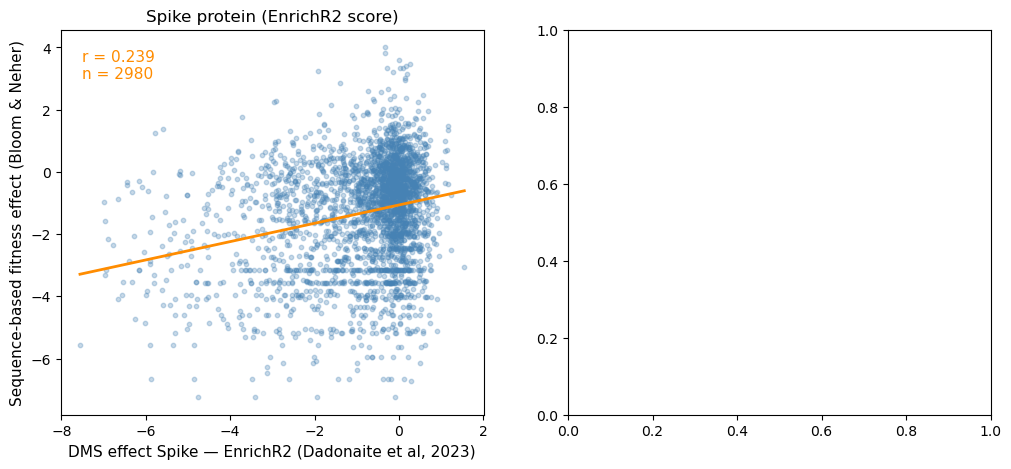

In [14]:
# ============================================================
#  Final correlation figure with EnrichR2 scores
# ============================================================

def safe_panel(ax, x_vals, y_vals, title, xlabel, ylabel, weights=None):
    x = np.asarray(x_vals, dtype=float)
    y = np.asarray(y_vals, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    if len(x) < 2:
        ax.text(0.5, 0.5, "NO DATA", transform=ax.transAxes, ha="center")
        return

    r, _ = stats.pearsonr(x, y)
    ax.scatter(x, y, alpha=0.3, s=10, color="steelblue")
    m, b = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, m * xline + b, color="darkorange", linewidth=2)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.text(0.05, 0.95, f"r = {r:.3f}\nn = {len(x)}",
            transform=ax.transAxes, va="top", color="darkorange", fontsize=11)
    print(f"  {title}: r={r:.3f}, n={len(x)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

safe_panel(
    axes[0],
    spike_comparison["dms_score_norm"],
    spike_comparison["fitness"],
    "Spike protein (EnrichR2 score)",
    "DMS effect Spike — EnrichR2 (Dadonaite et al, 2023)",
    "Sequence-based fitness effect (Bloom & Neher)"
)

safe_panel(
    axes[1],
    mpro_comparison["dms_score_avg"],
    mpro_comparison["fitness"],
    "Mpro (nsp5)",
    "DMS effect Mpro (Flynn et al, 2022)",
    "Sequence-based fitness effect (Bloom & Neher)"
)

plt.tight_layout()
plt.savefig("figure4_enrichR2.pdf", dpi=300, bbox_inches="tight")
plt.savefig("figure4_enrichR2.png", dpi=300, bbox_inches="tight")
plt.show()

Spike protein (EnrichR2 score): weighted r = 0.277, n = 2980


NameError: name 'mpro_comparison' is not defined

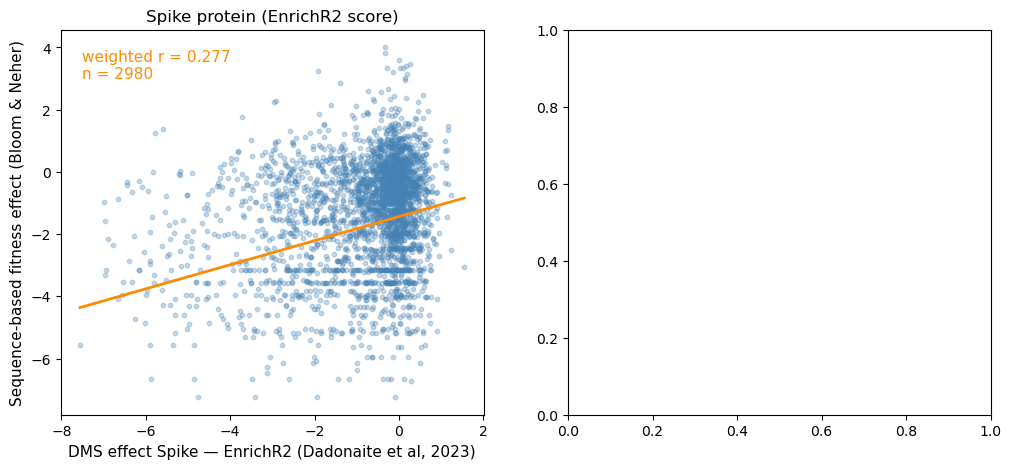

In [15]:
# ============================================================
#  Final correlation figure with WEIGHTED EnrichR2 correlation
# ============================================================

def safe_panel(ax, x_vals, y_vals, title,
               xlabel, ylabel, weights=None):

    x = np.asarray(x_vals, dtype=float)
    y = np.asarray(y_vals, dtype=float)

    if weights is not None:
        w = np.asarray(weights, dtype=float)

        mask = (
            np.isfinite(x) &
            np.isfinite(y) &
            np.isfinite(w) &
            (w > 0)
        )

        x, y, w = x[mask], y[mask], w[mask]

    else:
        mask = np.isfinite(x) & np.isfinite(y)
        x, y = x[mask], y[mask]

    if len(x) < 2:
        ax.text(0.5, 0.5, "NO DATA",
                transform=ax.transAxes,
                ha="center")
        return

    # --------------------------------------------------------
    # WEIGHTED Pearson correlation
    # --------------------------------------------------------
    if weights is not None:

        w = w / w.sum()

        mx = np.dot(w, x)
        my = np.dot(w, y)

        cov = np.dot(w, (x - mx) * (y - my))
        vx  = np.dot(w, (x - mx) ** 2)
        vy  = np.dot(w, (y - my) ** 2)

        r = cov / np.sqrt(vx * vy)

        # weighted regression line
        m, b = np.polyfit(x, y, 1, w=w)

    else:

        r, _ = stats.pearsonr(x, y)

        m, b = np.polyfit(x, y, 1)

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------
    ax.scatter(
        x, y,
        alpha=0.3,
        s=10,
        color="steelblue"
    )

    xline = np.linspace(x.min(), x.max(), 100)

    ax.plot(
        xline,
        m * xline + b,
        color="darkorange",
        linewidth=2
    )

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)

    ax.text(
        0.05,
        0.95,
        f"weighted r = {r:.3f}\nn = {len(x)}",
        transform=ax.transAxes,
        va="top",
        color="darkorange",
        fontsize=11
    )

    print(f"{title}: weighted r = {r:.3f}, n = {len(x)}")


# ============================================================
# MAKE FIGURE
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ------------------------------------------------------------
# Spike
# ------------------------------------------------------------
safe_panel(
    axes[0],
    spike_comparison["dms_score_norm"],
    spike_comparison["fitness"],
    "Spike protein (EnrichR2 score)",
    "DMS effect Spike — EnrichR2 (Dadonaite et al, 2023)",
    "Sequence-based fitness effect (Bloom & Neher)",
    weights=spike_comparison["expected_count"]
)

# ------------------------------------------------------------
# Mpro
# ------------------------------------------------------------
safe_panel(
    axes[1],
    mpro_comparison["dms_score_avg"],
    mpro_comparison["fitness"],
    "Mpro (nsp5)",
    "DMS effect Mpro (Flynn et al, 2022)",
    "Sequence-based fitness effect (Bloom & Neher)"
)

plt.tight_layout()

plt.savefig(
    "figure4_enrichR2_weighted.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "figure4_enrichR2_weighted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()